In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import vector
import mplhep as hep
import itertools
import math
vector.register_awkward()
plt.style.use(hep.style.CMS)

In [22]:
#4 Electron Code
Z_MASS = 91.1876  # Z boson mass (GeV)
def reco_higgs_to_4el(events):
    df_base = selection_4el(events)
    electron_p4 = ak.zip({
        "pt": events["Electron_pt"],
        "eta": events["Electron_eta"],
        "phi": events["Electron_phi"],
        "mass": events["Electron_mass"]
    }, with_name="PtEtaPhiMLorentzVector")
    electron_vec=vector.awk(ak.Array(electron_p4))
    Hcanidates=electron_vec[:,0]+electron_vec[:,1]+electron_vec[:,2]+electron_vec[:,3]
    Hmass=Hcanidates.mass
    return Hmass


def add_impact_params(events, particle, verbose = True):

    dxy = f"{particle}_dxy"
    dz = f"{particle}_dz"
    dxyErr = f"{particle}_dxyErr"
    dzErr = f"{particle}_dzErr"
    ip3d_column = f"{particle}_ip3d"
    sip3d_column = f"{particle}_sip3d"

    # Vectorized computation using Awkward Array broadcasting

    ip3d = np.sqrt(events[dxy] ** 2 + events[dz] ** 2)
    sip3d = ip3d / np.sqrt(events[dxyErr] ** 2 + events[dzErr] ** 2)

    events[ip3d_column] = ip3d
    events[sip3d_column] = sip3d

    if verbose:
        print(f"Added impact parameters for {particle}s to tree with {len(events)} events")
    return events

def selection_4el(events):
    electron_mask = (events["nElectron"] == 4) & (ak.all(np.abs(events["Electron_eta"]) < 2.5, axis=1)) & (ak.all(np.abs(events["Electron_pt"]) > 7, axis=1))
    isolation_mask = ak.all(events["Electron_pfRelIso03_all"] < 0.40, axis = 1)
    impact_parameter_mask = (ak.all(events["Electron_sip3d"] < 4, axis=1)) & (ak.all(np.abs(events["Electron_dxy"]) < 0.5, axis=1)) & (ak.all(np.abs(events["Electron_dz"]) < 1.0, axis=1))
    charge_mask = (ak.sum(events["Electron_charge"], axis=1) == 0)
    combined_mask = electron_mask & isolation_mask & impact_parameter_mask & charge_mask
    selected_events = events[combined_mask]
    return selected_events



In [23]:
#4 Muon Code
def reco_higgs_to_4mu(events):
    df_base = selection_4mu(events)
    muon_p4 = ak.zip({
        "pt": events["Muon_pt"],
        "eta": events["Muon_eta"],
        "phi": events["Muon_phi"],
        "mass": events["Muon_mass"]
    }, with_name="PtEtaPhiMLorentzVector")
    muon_vec=vector.awk(ak.Array(muon_p4))
    Hcanidates=muon_vec[:,0]+muon_vec[:,1]+muon_vec[:,2]+muon_vec[:,3]
    Hmass=Hcanidates.mass
    return Hmass



def selection_4mu(events):
    muon_mask = (events["nMuon"] == 4) & (ak.all(np.abs(events["Muon_eta"]) < 2.4, axis=1)) & (ak.all(np.abs(events["Muon_pt"]) > 5, axis=1))
    isolation_mask = ak.all(events["Muon_pfRelIso03_all"] < 0.40, axis=1)
    impact_parameter_mask = (ak.all(events["Muon_sip3d"] < 4, axis=1)) & (ak.all(np.abs(events["Muon_dxy"]) < 0.5, axis=1)) & (ak.all(np.abs(events["Muon_dz"]) < 1.0, axis=1))
    charge_mask = (ak.sum(events["Muon_charge"], axis=1) == 0)
    combined_mask = muon_mask & isolation_mask & impact_parameter_mask & charge_mask
    selected_events = events[combined_mask]
    return selected_events



In [24]:
#2e2mu code
def reco_higgs_to_2el2mu(events):
    df_base = selection_2el2mu(events)
    electron_p4 = ak.zip({
        "pt": events["Electron_pt"],
        "eta": events["Electron_eta"],
        "phi": events["Electron_phi"],
        "mass": events["Electron_mass"]
    }, with_name="PtEtaPhiMLorentzVector")
    muon_p4 = ak.zip({
        "pt": events["Muon_pt"],
        "eta": events["Muon_eta"],
        "phi": events["Muon_phi"],
        "mass": events["Muon_mass"]
    }, with_name="PtEtaPhiMLorentzVector")
    electron_vec=vector.awk(ak.Array(electron_p4))
    muon_vec=vector.awk(ak.Array(muon_p4))
    Hcanidates=muon_vec[:,0]+muon_vec[:,1]+electron_vec[:,0]+electron_vec[:,1]
    Hmass=Hcanidates.mass
    return Hmass



def selection_2el2mu(events):
    muon_mask = (events["nMuon"] == 2) & (ak.all(np.abs(events["Muon_eta"]) < 2.4, axis=1)) & (ak.all(np.abs(events["Muon_pt"]) > 5, axis=1))
    electron_mask = (events["nElectron"] == 2) & (ak.all(np.abs(events["Electron_eta"]) < 2.5, axis=1)) & (ak.all(np.abs(events["Electron_pt"]) > 7, axis=1))
    isolation_mask = (ak.all(events["Muon_pfRelIso03_all"] < 0.40, axis=1)) & (ak.all(events["Electron_pfRelIso03_all"] < 0.40, axis = 1))
    impact_parameter_mask_muon = (ak.all(events["Muon_sip3d"] < 4, axis=1)) & (ak.all(np.abs(events["Muon_dxy"]) < 0.5, axis=1)) & (ak.all(np.abs(events["Muon_dz"]) < 1.0, axis=1))
    impact_parameter_mask_electron = (ak.all(events["Electron_sip3d"] < 4, axis=1)) & (ak.all(np.abs(events["Electron_dxy"]) < 0.5, axis=1)) & (ak.all(np.abs(events["Electron_dz"]) < 1.0, axis=1))
    charge_mask = (ak.sum(events["Muon_charge"], axis=1) == 0) & (ak.sum(events["Electron_charge"], axis=1) == 0)
    combined_mask = muon_mask & electron_mask & isolation_mask & impact_parameter_mask_muon & impact_parameter_mask_electron & charge_mask
    selected_events = events[combined_mask]
    return selected_events



In [65]:
nbins = 30

# Weights
luminosity = 11580.0  # Integrated luminosity of the data samples

xsec_ZZTo4mu = 0.077  # ZZ->4mu: Standard Model cross-section
nevt_ZZTo4mu = 1499064.0  # ZZ->4mu: Number of simulated events

xsec_ZZTo4el = 0.077  # ZZ->4el: Standard Model cross-section
nevt_ZZTo4el = 1499093.0  # ZZ->4el: Number of simulated events

xsec_ZZTo2el2mu = 0.18  # ZZ->2el2mu: Standard Model cross-section
nevt_ZZTo2el2mu = 1497445.0  # ZZ->2el2mu: Number of simulated events

xsec_SMHiggsToZZTo4L = 0.0065  # H->4l: Standard Model cross-section
nevt_SMHiggsToZZTo4L = 299973.0  # H->4l: Number of simulated events
scale_ZZTo4l = 1.386  # ZZ->4l: Scale factor for ZZ to four leptons

weight_sig_4mu = luminosity * xsec_SMHiggsToZZTo4L / nevt_SMHiggsToZZTo4L
weight_bkg_4mu = luminosity * xsec_ZZTo4mu * scale_ZZTo4l / nevt_ZZTo4mu

weight_sig_4el = luminosity * xsec_SMHiggsToZZTo4L / nevt_SMHiggsToZZTo4L
weight_bkg_4el = luminosity * xsec_ZZTo4el * scale_ZZTo4l / nevt_ZZTo4el

weight_sig_2el2mu = luminosity * xsec_SMHiggsToZZTo4L / nevt_SMHiggsToZZTo4L
weight_bkg_2el2mu = luminosity * xsec_ZZTo2el2mu * scale_ZZTo4l / nevt_ZZTo2el2mu

# Plot results function (you can modify the plotting style)
#obtain signal_masses from the signal file(SMHiggsToZZTo4L.root) and background_masses from background file (ZZTo4e.root, ZZTo2e2mu.root , ZZTo4mu.root)
def plot_results(signal_masses, background_masses, weight_signal, weight_bkg, x_label):
    bins = np.linspace(40, 180, nbins)

    # Create the figure and axis objects
    fig, ax = plt.subplots(figsize=(8, 7))

    # Plot the background and signal as step histograms
    ax.hist(background_masses, bins=bins, histtype='step',
            weights=[weight_bkg] * len(background_masses),
            label='Background', linewidth=3, color='blue')

    ax.hist(signal_masses, bins=bins, histtype='step',
            weights=[weight_signal] * len(signal_masses),
            label='Signal', linewidth=3, color='red')

    # Add labels and title
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel('Number of Events', fontsize=14)

    # CMS-style text
    ax.text(0.05, 1.02, r'$\mathbf{CMS \ Open \ Data}$', transform=ax.transAxes, fontsize=14)
    ax.text(0.6, 1.02, r'$\sqrt{s} = 8 \ \mathrm{TeV}, L_{int} = 11.6 \ \mathrm{fb}^{-1}$', transform=ax.transAxes, fontsize=12)

    # Add a legend
    ax.legend(loc='upper right', fontsize=14)

    # Display the plot
    plt.show()


In [26]:
file_bkg_el = uproot.open('/home/bhanda25/Phys323_fall2024/Root_files/ZZTo4e.root')
tree_bkg_el = file_bkg_el['Events']
branches_el = tree_bkg_el.arrays(
    [
        "nElectron",
        "Electron_pt",
        "Electron_eta",
        "Electron_phi",
        "Electron_mass",
        "Electron_charge",
        "Electron_pfRelIso03_all",
        "Electron_dz",
        "Electron_dxy",
        "Electron_dxyErr",
        "Electron_dzErr"
    ],
    library="ak")

add_impact_params(branches_el, "Electron")

Added impact parameters for Electrons to tree with 72853 events


<Array [{nElectron: 4, ...}, {...}, ..., {...}] type='72853 * {nElectron: u...'>

In [27]:
file_bkg_mu = uproot.open('/home/bhanda25/Phys323_fall2024/Root_files/ZZTo4mu.root')
tree_bkg_mu = file_bkg_mu['Events;1']
branches_mu = tree_bkg_mu.arrays(
    [
        "nMuon",
        "Muon_pt",
        "Muon_eta",
        "Muon_phi",
        "Muon_mass",
        "Muon_pfRelIso03_all",
        "Muon_dxy",
        "Muon_dz",
        "Muon_dxyErr",
        "Muon_dzErr",
        "Muon_charge"
    ],
    library="ak")
add_impact_params(branches_mu, "Muon")

Added impact parameters for Muons to tree with 122799 events


<Array [{nMuon: 4, Muon_pt: [...], ...}, ...] type='122799 * {nMuon: uint32...'>

In [28]:
#DON'T FORGET TO RUN IMPACT PARAMS TWICE!!
file_bkg_elmu = uproot.open('/home/bhanda25/Phys323_fall2024/Root_files/ZZTo2e2mu.root')
tree_bkg_elmu = file_bkg_elmu['Events;1']
branches_elmu = tree_bkg_elmu.arrays(
    [
        "nElectron",
        "Electron_pt",
        "Electron_eta",
        "Electron_phi",
        "Electron_mass",
        "Electron_charge",
        "Electron_pfRelIso03_all",
        "Electron_dz",
        "Electron_dxy",
        "Electron_dxyErr",
        "Electron_dzErr",
        "nMuon",
        "Muon_pt",
        "Muon_eta",
        "Muon_phi",
        "Muon_mass",
        "Muon_pfRelIso03_all",
        "Muon_dxy",
        "Muon_dz",
        "Muon_dxyErr",
        "Muon_dzErr",
        "Muon_charge"
    ],
    library="ak")

add_impact_params(branches_elmu, "Electron")
add_impact_params(branches_elmu, "Muon")

Added impact parameters for Electrons to tree with 82669 events
Added impact parameters for Muons to tree with 82669 events


<Array [{nElectron: 2, ...}, {...}, ..., {...}] type='82669 * {nElectron: u...'>

In [29]:
file_sig = uproot.open('/home/bhanda25/Phys323_fall2024/Root_files/SMHiggsToZZTo4L.root')
tree_sig = file_sig["Events;1"]
branches_sig = tree_sig.arrays(
    [
        "nElectron",
        "Electron_pt",
        "Electron_eta",
        "Electron_phi",
        "Electron_mass",
        "Electron_charge",
        "Electron_pfRelIso03_all",
        "Electron_dz",
        "Electron_dxy",
        "Electron_dxyErr",
        "Electron_dzErr",
        "nMuon",
        "Muon_pt",
        "Muon_eta",
        "Muon_phi",
        "Muon_mass",
        "Muon_pfRelIso03_all",
        "Muon_dxy",
        "Muon_dz",
        "Muon_dxyErr",
        "Muon_dzErr",
        "Muon_charge"
    ],
    library="ak")

add_impact_params(branches_sig, "Muon")
add_impact_params(branches_sig, "Electron")

Added impact parameters for Muons to tree with 29381 events
Added impact parameters for Electrons to tree with 29381 events


<Array [{nElectron: 0, ...}, {...}, ..., {...}] type='29381 * {nElectron: u...'>

In [30]:
sig_4el_mask = branches_sig["nElectron"] == 4
sig_4el_filtered = branches_sig[sig_4el_mask]
mass_sig_4el = ak.to_numpy(reco_higgs_to_4el(sig_4el_filtered))

In [31]:
mass_bkg_4el = ak.to_numpy(reco_higgs_to_4el(branches_el))

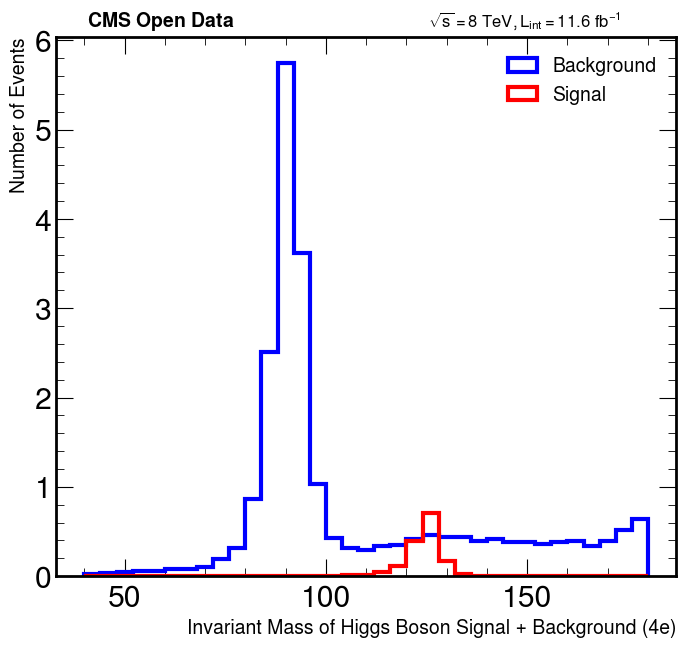

[125.216515 126.33967  126.891014 ... 123.88161  126.07398  125.82037 ]
[184.9526  155.58408 246.96692 ... 279.78415  97.17173 257.01056]


In [47]:
plot_results(mass_sig_4el, mass_bkg_4el, weight_sig_4el, weight_bkg_4el, "Invariant Mass of Higgs Boson Signal + Background (4e)")
print(mass_sig_4el)
print(mass_bkg_4el)

In [48]:
sig_4mu_mask = branches_sig["nMuon"] == 4
sig_4mu_filtered = branches_sig[sig_4mu_mask]
mass_sig_4mu = ak.to_numpy(reco_higgs_to_4mu(sig_4mu_filtered))

In [49]:
mass_bkg_4mu = ak.to_numpy(reco_higgs_to_4mu(branches_mu))

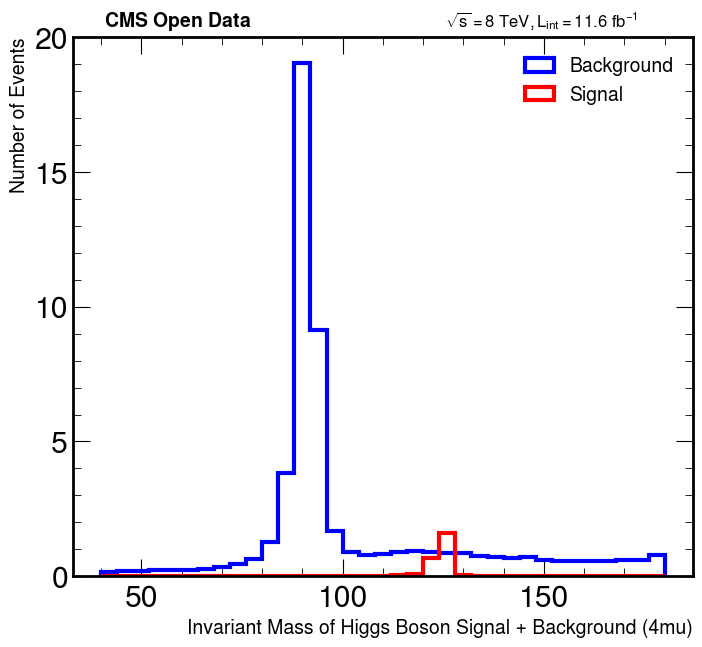

In [50]:
plot_results(mass_sig_4mu, mass_bkg_4mu, weight_sig_4mu, weight_bkg_4mu, "Invariant Mass of Higgs Boson Signal + Background (4mu)")

In [51]:
sig_2el2mu_mask = (branches_sig["nElectron"] == 2) & (branches_sig["nMuon"] == 2)
sig_2el2mu_filtered = branches_sig[sig_2el2mu_mask]
mass_sig_2el2mu = ak.to_numpy(reco_higgs_to_2el2mu(sig_2el2mu_filtered))

In [52]:
mass_bkg_2el2mu = ak.to_numpy(reco_higgs_to_2el2mu(branches_elmu))

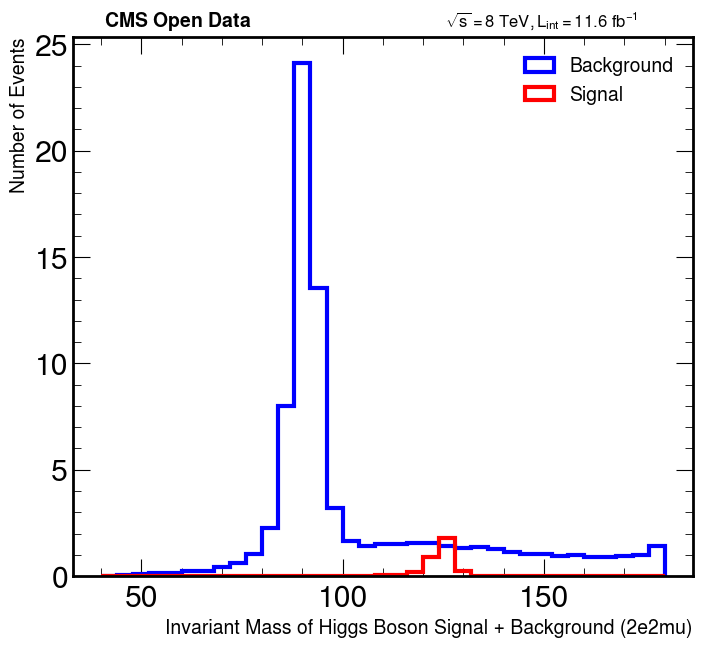

In [53]:
plot_results(mass_sig_2el2mu, mass_bkg_2el2mu, weight_sig_2el2mu, weight_bkg_2el2mu, "Invariant Mass of Higgs Boson Signal + Background (2e2mu)")

In [54]:
mass_sig_all = np.concatenate((mass_sig_4el, mass_sig_4mu, mass_sig_2el2mu))
mass_bkg_all = np.concatenate((mass_bkg_4el, mass_bkg_4mu, mass_bkg_2el2mu))

In [55]:
weight_sig_all = weight_sig_4el + weight_sig_4mu + weight_sig_2el2mu
weight_bkg_all = weight_bkg_4el + weight_bkg_4mu + weight_bkg_2el2mu

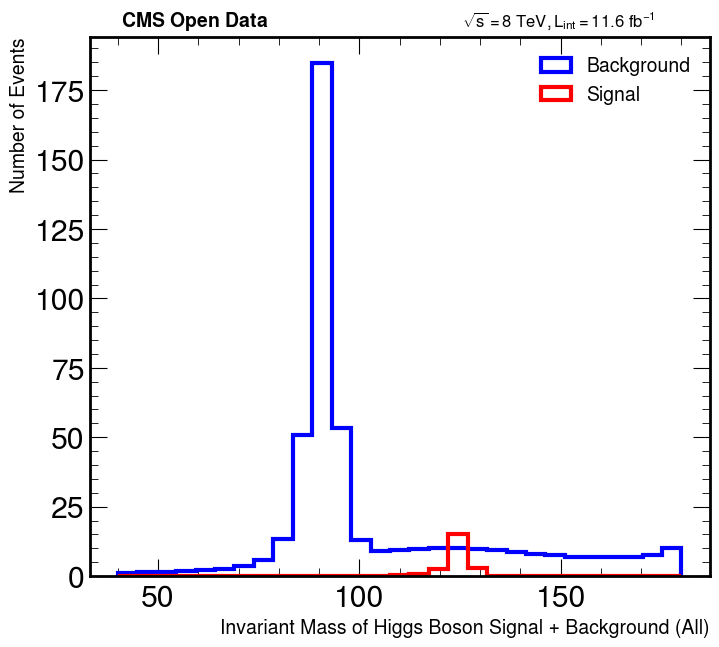

In [66]:
plot_results(mass_sig_all, mass_bkg_all, weight_sig_all, weight_bkg_all, "Invariant Mass of Higgs Boson Signal + Background (All)")